In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## Building a Linear Regression Model from Scratch

In [2]:
class UnivariateLinearRegression:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta = None
        self.loss_history = []
        self.theta_history = []
    
    def compute_loss(self, y_pred, y):
        m = y.shape[0]
        return ((1 / (2 * m)) * np.sum((y_pred - y)**2))
    
    def compute_gradients(self, X, y, y_pred, theta):
        m = y.shape[0]
        # Compute gradient descent
        gradient = (1 / m) * np.dot(X.T, (y_pred - y))
        # Update theta
        theta = theta - self.learning_rate * gradient
        return theta
    
    def fit(self, X, y):
        X = X.to_numpy()
        y = y.to_numpy()
        X = X.reshape(-1, 1)
        y = y.reshape(-1, 1)
        
        # Add bias 
        X = np.hstack((np.ones((X.shape[0],1)), X)) # shape (m, 2)
        # Initialize parameters
        self.theta = np.zeros((X.shape[1], 1)) # shape (2,1)
         
        
        # Training loop
        for i in range(self.n_iters):
            y_pred = np.dot(X, self.theta)
            loss = self.compute_loss(y_pred, y)

            self.loss_history.append(loss)
            self.theta_history.append(self.theta.copy())

            if i % 100 == 0:
                print(f"Iteration {i}: MSE Loss = {loss:.4f}")

            self.theta = self.compute_gradients(X, y, y_pred, self.theta)

        return self.theta
    
    def predict(self, X):
        X = X.to_numpy()
    
        X = X.reshape(-1, 1)

        # Add bias term for prediction
        ones_column = np.ones((X.shape[0], 1))
        X = np.hstack((ones_column, X))
        return np.dot(X, self.theta)
    

In [3]:
df = pd.read_csv("salary_dataset.csv")
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [4]:
df.drop('Unnamed: 0', axis = 1, inplace = True)

In [5]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [7]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


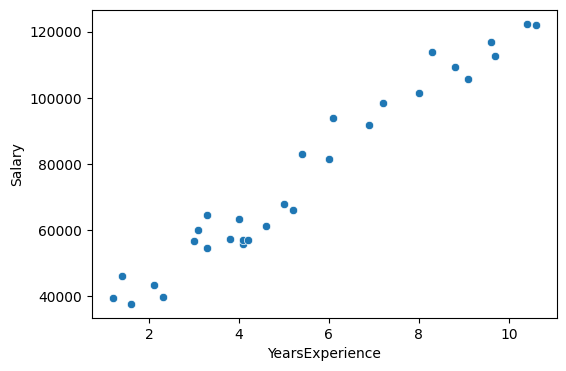

In [8]:
plt.figure(figsize = (6, 4))
sns.scatterplot(x = df['YearsExperience'], y = df['Salary'])
plt.show()


In [9]:
X_train, X_test, y_train, y_test = train_test_split(df[['YearsExperience']], df[['Salary']], test_size=0.3, random_state=42)

In [10]:
print(y_train)

      Salary
0    39344.0
4    39892.0
16   66030.0
5    56643.0
13   57082.0
11   55795.0
22  101303.0
1    46206.0
2    37732.0
25  105583.0
3    43526.0
21   98274.0
26  116970.0
18   81364.0
29  121873.0
20   91739.0
7    54446.0
10   63219.0
14   61112.0
19   93941.0
6    60151.0


In [11]:
linear_model = UnivariateLinearRegression(n_iters = 1000)
linear_model.fit(X_train, y_train)

Iteration 0: MSE Loss = 2864526194.2143
Iteration 100: MSE Loss = 53581773.8207
Iteration 200: MSE Loss = 39188484.6243
Iteration 300: MSE Loss = 30090779.4503
Iteration 400: MSE Loss = 24340305.1630
Iteration 500: MSE Loss = 20705547.3976
Iteration 600: MSE Loss = 18408090.9873
Iteration 700: MSE Loss = 16955915.5474
Iteration 800: MSE Loss = 16038025.0060
Iteration 900: MSE Loss = 15457845.0753


array([[22668.49071567],
       [ 9701.1471227 ]])

In [12]:
y_prediction = linear_model.predict(X_test)

In [13]:
print(y_prediction)

[[116769.61780589]
 [ 71174.22632919]
 [103188.01183411]
 [ 75054.68517827]
 [ 54682.27622059]
 [ 59532.84978194]
 [123560.42079178]
 [108038.58539546]
 [ 62443.19391876]]


## Using SkLearn Model


In [14]:
sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train)

LinearRegression()

In [17]:
y_prediction_sk = sklearn_model.predict(X_test)

In [18]:
print(y_prediction_sk)

[[115574.62288352]
 [ 71680.93878159]
 [102499.90847018]
 [ 75416.57147111]
 [ 55804.4998511 ]
 [ 60474.04071301]
 [122111.98009019]
 [107169.44933209]
 [ 63275.76523015]]


### Calculate the difference in prediction

In [19]:
print(y_prediction - y_prediction_sk)

[[ 1194.99492237]
 [ -506.7124524 ]
 [  688.10336393]
 [ -361.88629284]
 [-1122.22363051]
 [ -941.19093106]
 [ 1448.44070159]
 [  869.13606337]
 [ -832.5713114 ]]


## Evaluation Metrics

In [28]:
def mean_squared_error(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    return np.mean((y_true - y_pred) ** 2)

def mean_absolute_error(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    return np.mean(np.abs(y_true - y_pred))

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def r2_score(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

def evaluate_all(y_true, y_pred):
    return {
        'MSE': mean_squared_error(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

In [29]:
mse = mean_squared_error(y_test, y_prediction)
print(f"The mean squared error is:{mse:.4f}")
r2 = r2_score(y_test, y_prediction)
print(f"The R Squared Error is:{r2:.4f}")


The mean squared error is:37689720.5134
The R Squared Error is:0.9416


### Comparing metrics of the custom build and sklearn model

In [32]:
custom_metrics = evaluate_all(y_test, y_prediction)
sklearn_metrics = evaluate_all(y_test, y_prediction_sk)

In [35]:
df = pd.DataFrame({
    'Metric': list(custom_metrics.keys()),
    'Custom Model': list(custom_metrics.values()),
    'Sklearn Model': list(sklearn_metrics.values())
})
print(df)

  Metric  Custom Model  Sklearn Model
0    MSE  3.768972e+07   3.778466e+07
1    MAE  5.131306e+03   5.161329e+03
2   RMSE  6.139195e+03   6.146923e+03
3     R2  9.415938e-01   9.414466e-01
